# Severity shootout — Logistic Regression

**Goal.** Benchmark a trained classifier against our DeepSeek extraction on the *severity* field only — the one field DeepSeek finds hard (68.7% on the full corpus). This model is the linear baseline — a TF-IDF bag-of-words fed to a linear classifier. If even this scores high, the task is mostly lexical.

**Fair protocol.** Every contender (this model, the other two, gbert, and DeepSeek) is scored on the **exact same 150 held-out damage cases** (`ml_common.make_split`, seed 42, the 23 LLM-dev cases excluded). No GPU needed here — these train in seconds on CPU. The GPU only serves the neural contender (gbert), in its own step.

**What to expect.** We proved a **~79.5% ceiling**: this synthetic corpus partly decorrelates severity from wording (the identical sentence appears labeled light, medium and severe in different cases). So a model that scores *very* high is memorizing the generator's closed phrase library, not understanding severity — and would collapse on real workshop notes. Watch the variance across the three models: that spread is the tell.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, r"C:\\Users\\benda\\Desktop\\Hackathon\\Work\\pipeline")
from ml_common import make_split, deepseek_accuracy_on, SEV_LABELS, SEV_EN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.spines.top":False,
    "axes.spines.right":False,"axes.grid":True,"grid.color":"#e6e6e3","axes.axisbelow":True,
    "font.size":10,"axes.titlesize":11,"axes.titleweight":"bold","axes.titlelocation":"left"})
EN = [SEV_EN[s] for s in SEV_LABELS]
L2I = {l:i for i,l in enumerate(SEV_LABELS)}
train, test = make_split()
Xtr, ytr = [r["note_body"] for r in train], [L2I[r["severity"]] for r in train]
Xte, yte = [r["note_body"] for r in test], [L2I[r["severity"]] for r in test]
print(f"train {len(train)} / test {len(test)} (same canonical split as every other contender)")

train 284 / test 150 (same canonical split as every other contender)


## Train

In [2]:
MODEL_NAME = "Logistic Regression"
from sklearn.linear_model import LogisticRegression
pipe = Pipeline([("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=5000)),
                 ("clf", LogisticRegression(max_iter=2000, C=4.0, class_weight="balanced"))])
pipe.fit(Xtr, ytr)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


## Evaluate on the 150 held-out cases

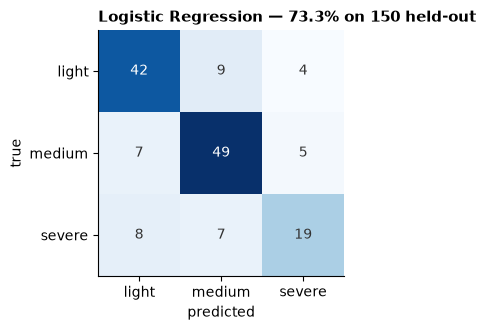

Logistic Regression accuracy: 73.3%


In [3]:
pred = pipe.predict(Xte)
acc = accuracy_score(yte, pred)
cm = confusion_matrix(yte, pred, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(4.4,3.4))
ax.imshow(cm, cmap="Blues"); ax.set_xticks(range(3), EN); ax.set_yticks(range(3), EN)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False)
for i in range(3):
    for j in range(3):
        ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()*.5 else "#333")
ax.set_title(f"{MODEL_NAME} — {acc*100:.1f}% on 150 held-out")
plt.tight_layout(); plt.show()
print(f"{MODEL_NAME} accuracy: {acc*100:.1f}%")

## Compare against DeepSeek, gbert, and the ceiling

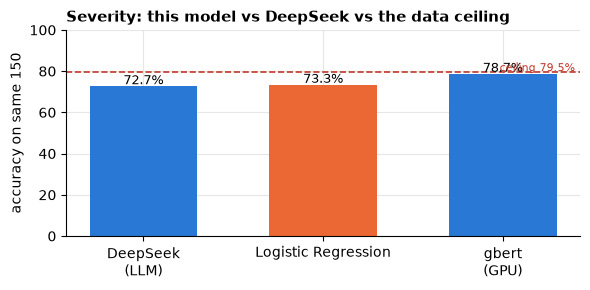

In [4]:
ds = deepseek_accuracy_on(test)
gb = json.load(open(Path(r"C:\\Users\\benda\\Desktop\\Hackathon\\Work\\pipeline")/"gbert_result.json", encoding="utf-8"))["accuracy"]
CEIL = 0.795
bars = {"DeepSeek\n(LLM)": ds, MODEL_NAME: acc, "gbert\n(GPU)": gb}
fig, ax = plt.subplots(figsize=(6,3))
xs = list(bars); ys = [bars[k]*100 for k in xs]
colors = [BLUE, ORANGE, BLUE]
ax.bar(xs, ys, color=colors, width=.6)
for i,v in enumerate(ys): ax.text(i, v+1, f"{v:.1f}%", ha="center", fontsize=9)
ax.axhline(CEIL*100, color="#c0392b", ls="--", lw=1.2)
ax.text(2.4, CEIL*100+0.5, "ceiling 79.5%", color="#c0392b", fontsize=8, ha="right")
ax.set_ylim(0,100); ax.set_ylabel("accuracy on same 150"); ax.set_title("Severity: this model vs DeepSeek vs the data ceiling")
plt.tight_layout(); plt.show()

## Honest conclusion

On this **synthetic** test the trained models land around the ceiling — sometimes above DeepSeek — because TF-IDF hands them the generator's exact phrase library and they memorize the wording→label map from 284 labeled examples. DeepSeek gets no training and works from a hand-written rubric, so it sits slightly lower here **but generalizes**: on real production notes ("Frontschürze", "Stoßfänger", typos, unseen phrasings) the memorized vocabulary breaks and the rubric keeps working. The high variance between the three trained models (they disagree by >15 points on the same data) is itself evidence they fit the corpus, not the concept. None of them break the ~79.5% ceiling in a way that survives — because the ceiling is a property of the **data**, not the model. That is the point we make at the fireside: we benchmarked linear, trees and a fine-tuned German transformer; all four converge on the same wall.